# 01 — Experiment Audit

## Objective

Before estimating the treatment effect, verify that the experiment data is reliable enough to analyse.

The experiment compares:

- Control: progression gate at level 30
- Treatment: progression gate at level 40

At this stage, I am not evaluating which variant performs better.

The goal is to check:

1. Dataset structure
2. Missing values
3. Duplicate users
4. Treatment allocation
5. Sample balance
6. Potential Sample Ratio Mismatch
7. Unusual or invalid values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/Users/janhavisingh/personal_projects/mobile-game-experimentation/data/cookie_cats.csv")

In [6]:
df.shape

(90189, 5)

In [7]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [9]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [10]:
df["userid"].nunique()

90189

In [11]:
df["userid"].duplicated().sum()

np.int64(0)

In [12]:
df["version"].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [13]:
df["version"].value_counts(normalize=True)

version
gate_40    0.504374
gate_30    0.495626
Name: proportion, dtype: float64

In [15]:
df[["sum_gamerounds"]].describe()

,sum_gamerounds
count,90189.000000
mean,51.872457
std,195.050858
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,49854.000000


In [16]:
df["retention_1"].value_counts(dropna=False)

retention_1
False    50036
True     40153
Name: count, dtype: int64

In [17]:
df["retention_7"].value_counts(dropna=False)

retention_7
False    73408
True     16781
Name: count, dtype: int64

In [18]:
df.groupby("version")["retention_7"].mean()

version
gate_30    0.190201
gate_40    0.182000
Name: retention_7, dtype: float64

## Experiment Audit Summary

### Data quality
The dataset contains no missing values and no duplicate user IDs, so each user appears once and the experimental unit is preserved.

### Randomisation
Treatment allocation is approximately balanced:

- gate_30: 49.56%
- gate_40: 50.44%

This suggests the experiment was likely designed with an approximately 50/50 allocation.

### Potential concerns
No obvious data quality issues have been identified so far. However, the observed treatment split should be formally tested for Sample Ratio Mismatch rather than judged visually.

### Can the experiment proceed to outcome analysis?
Provisionally yes. The dataset appears suitable for experimentation analysis, subject to confirming that there is no statistically significant Sample Ratio Mismatch.

In [20]:
# Test for Sample Ratio Mismatch
counts = df["version"].value_counts()
counts

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [22]:
expected = [len(df) / 2, len(df) / 2]
expected

[45094.5, 45094.5]

Null hypothesis: users were allocated according to the expected 50/50 split.

Then decide:
- if p < 0.05 → evidence of Sample Ratio Mismatch
- if p >= 0.05 → no evidence of Sample Ratio Mismatch

In [23]:
from scipy.stats import chisquare

chi2, p_value = chisquare(
    f_obs=counts.values,
    f_exp=expected
)

chi2, p_value

(np.float64(6.9024049496058275), np.float64(0.008607987810836243))

### Sample Ratio Mismatch

A chi-square goodness-of-fit test was used to compare the observed
treatment allocation with the expected 50/50 allocation.

χ² = 6.90, p = 0.0086.

At a 5% significance level, this provides evidence that the observed
allocation differs from an exact 50/50 split.

However, the absolute imbalance is small (49.56% vs 50.44%). Given the
large experiment sample, even small deviations can become statistically
detectable.

The result should therefore be treated as a potential experiment-health
warning rather than immediate evidence that the experiment is invalid.
The cause of the mismatch would ideally be investigated before making a
launch decision based on treatment outcomes.

In [24]:
df[["sum_gamerounds", "retention_1", "retention_7"]].describe()

,sum_gamerounds
count,90189.000000
mean,51.872457
std,195.050858
min,0.000000
25%,5.000000
50%,16.000000
75%,51.000000
max,49854.000000


In [25]:
df["sum_gamerounds"].min(), df["sum_gamerounds"].max()

(np.int64(0), np.int64(49854))

In [26]:
df.nlargest(10, "sum_gamerounds")[["userid", "version", "sum_gamerounds"]]

,userid,version,sum_gamerounds
57702,6390605,gate_30,49854
7912,871500,gate_30,2961
29417,3271615,gate_40,2640
43671,4832608,gate_30,2438
48188,5346171,gate_40,2294
46344,5133952,gate_30,2251
87007,9640085,gate_30,2156
36933,4090246,gate_40,2124
88328,9791599,gate_40,2063
6536,725080,gate_40,2015


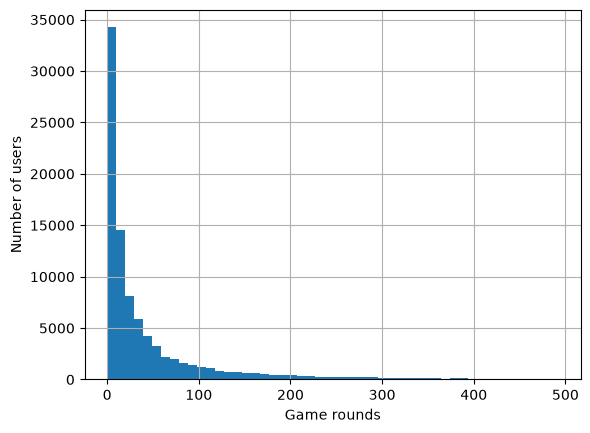

In [27]:
df[df["sum_gamerounds"] < df["sum_gamerounds"].quantile(0.99)]["sum_gamerounds"].hist(bins=50)
plt.xlabel("Game rounds")
plt.ylabel("Number of users")
plt.show()

sum_gamerounds is strongly right-skewed, with most users concentrated at lower engagement levels and a long tail of highly active players. The maximum value of 49,854 appears extreme relative to the wider distribution and should be investigated separately. Because engagement is highly skewed, mean-based comparisons may be sensitive to outliers and should be supplemented with robust summaries or bootstrap confidence intervals.